# Inter-Uni Datathon 
## Stream 1 - Default of Credit Card Clients 

**Author:** Gousia  Ain, University of Sydney (solo entry)

**Metric:** binary log loss (lower is better)

**Final leaderboard score:** 0.41200

**Final cross-validated score:** 0.42409 (5-fold stratified, sd 0.0060)

## Problem and approach

We estimate each customer's probability of defaulting on their next payment. Because the
metric is log loss rather than accuracy or AUC, the deliverable is not a good *ranking* of
customers but a set of *honest probabilities*: a customer assigned 0.30 should default
about 30% of the time.

Two consequences shape everything below.

1. **No class rebalancing.** SMOTE, class weighting and `scale_pos_weight` all deliberately
   distort predicted probabilities in order to improve threshold-based metrics. Log loss
   penalises exactly that distortion. None are used here.
2. **Every claimed improvement is tested against its uncertainty.** Cross-validated scores
   are reported with the standard deviation across folds, model comparisons use paired
   tests on identical folds, and differences smaller than that uncertainty are reported as
   noise rather than progress.

## Contents

1. Setup and data loading
2. Data quality checks
3. Exploratory analysis
4. Feature engineering
5. Validation strategy
6. Model selection
7. Responsible use of demographic information
8. Final model and submission
9. Calibration
10. Interpretability
11. Fairness audit
12. Cost asymmetry and lending policy
13. Experiments that did not make the final model
14. Limitations

## 1. Setup and data loading

Everything random is seeded, so running this again produces the same submission file.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from lightgbm import LGBMClassifier
from scipy import stats

warnings.filterwarnings('ignore')

# Seeded in three places: Python's RNG, NumPy's, and the hash seed. The models are
# seeded individually where they are constructed.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# The competition CSVs are expected in the same directory as this notebook.
DATA_DIR = '.'

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

TARGET = 'default'
ID     = 'client_id'

# Column groups, referenced throughout. The competition data has no PAY_1 column;
# the most recent month is PAY_0 and the series continues PAY_2 ... PAY_6.
PAY_COLS  = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
BILL_COLS = [f'BILL_AMT{i}' for i in range(1, 7)]
AMT_COLS  = [f'PAY_AMT{i}'  for i in range(1, 7)]

print('train:', train.shape)
print('test :', test.shape)

train: (24000, 25)
test : (6000, 24)


## 2. Data quality checks

### Data dictionary (from the competition materials)

- `client_id` — non-informative competition identifier
- `LIMIT_BAL` — granted credit in NT dollars
- `SEX` — source-coded sex category
- `EDUCATION` — source-coded education category
- `MARRIAGE` — source-coded marital-status category
- `AGE` — age in years
- `PAY_0`, `PAY_2` … `PAY_6` — recent repayment-status history
- `BILL_AMT1` … `BILL_AMT6` — monthly bill statement amounts in NT dollars
- `PAY_AMT1` … `PAY_AMT6` — monthly previous-payment amounts in NT dollars
- `default` — training target; 1 = default, 0 = no default

The competition materials do not define the individual codes inside the categorical
columns, so no external decoding is assumed anywhere in this notebook. Categories are
referred to by their code, and the behaviour of the `PAY_` values is established
empirically in section 3 rather than taken from any outside source.

In [2]:
print('missing values      :', train.isna().sum().sum())
print('duplicate client_id :', train[ID].duplicated().sum())
print('duplicate rows      :', train.drop(columns=[ID]).duplicated().sum())
print('target column       :', [x for x in train.columns if x not in test.columns])

# The 27 fully duplicated feature rows are retained. In a dataset of anonymised
# financial records, identical rows are plausible coincidences rather than data errors,
# and dropping them changed the cross-validated score by less than 0.0001.

# Do train and test look like the same population? A large shift here would invalidate
# cross-validation as an estimate of leaderboard performance.
drift = pd.DataFrame({
    'train_mean': train.drop(columns=[ID, TARGET]).mean(),
    'test_mean' : test.drop(columns=[ID]).mean(),
})
drift['pct_diff'] = ((drift.test_mean - drift.train_mean) / drift.train_mean.abs() * 100).round(2)
print()
print(drift.round(2).to_string())

missing values      : 0
duplicate client_id : 0
duplicate rows      : 27
target column       : ['default']

           train_mean  test_mean  pct_diff
LIMIT_BAL   167608.74  166986.67     -0.37
SEX              1.60       1.61      0.61
EDUCATION        1.85       1.86      0.66
MARRIAGE         1.55       1.57      1.26
AGE             35.54      35.26     -0.78
PAY_0           -0.02      -0.00     79.87
PAY_2           -0.14      -0.12     11.95
PAY_3           -0.17      -0.16      6.95
PAY_4           -0.22      -0.20      9.63
PAY_5           -0.27      -0.25      6.43
PAY_6           -0.30      -0.27      9.18
BILL_AMT1    51190.57   51354.38      0.32
BILL_AMT2    49051.11   49690.92      1.30
BILL_AMT3    46859.05   47629.59      1.64
BILL_AMT4    43175.80   43611.55      1.01
BILL_AMT5    40271.75   40469.99      0.49
BILL_AMT6    38743.09   39386.45      1.66
PAY_AMT1      5711.71    5471.06     -4.21
PAY_AMT2      5955.19    5785.06     -2.86
PAY_AMT3      5262.75    5077.42

### The baseline to beat

Predicting the overall default rate for every customer is the score any model must beat.
The competition's own `sample_submission.csv` does exactly this and scores 0.52831 on the
leaderboard, which confirms our local calculation is measuring the same quantity.

In [3]:
base_rate = train[TARGET].mean()
baseline  = log_loss(train[TARGET], np.full(len(train), base_rate))

print('default rate       :', round(base_rate, 5))
print('baseline log loss  :', round(baseline, 5))

# How harshly log loss punishes a confident mistake, per row. This is why the model must
# never be pushed toward extreme probabilities it cannot justify.
penalties = pd.DataFrame([
    {'predicted': p,
     'penalty_if_default':    round(-np.log(p), 3),
     'penalty_if_no_default': round(-np.log(1 - p), 3)}
    for p in [0.99, 0.9, 0.75, 0.5, 0.25, 0.1, 0.01]
])
print()
print(penalties.to_string(index=False))

default rate       : 0.22121
baseline log loss  : 0.52843

 predicted  penalty_if_default  penalty_if_no_default
      0.99               0.010                  4.605
      0.90               0.105                  2.303
      0.75               0.288                  1.386
      0.50               0.693                  0.693
      0.25               1.386                  0.288
      0.10               2.303                  0.105
      0.01               4.605                  0.010


## 3. Exploratory analysis

Exploration was aimed at decisions rather than description. Three findings below changed
how the model was built.

In [4]:
# Finding 1: the PAY_ columns are not an ordered risk scale.
for col in PAY_COLS:
    tab = train.groupby(col)[TARGET].agg(n='size', default_rate='mean')
    tab['default_rate'] = tab['default_rate'].round(4)
    print(f'--- {col} ---')
    print(tab.to_string())
    print()

--- PAY_0 ---
           n  default_rate
PAY_0                     
-2      2241        0.1343
-1      4561        0.1644
 0     11739        0.1280
 1      2944        0.3434
 2      2147        0.6907
 3       262        0.7519
 4        56        0.6429
 5        18        0.5000
 6        11        0.5455
 7         6        0.6667
 8        15        0.6000

--- PAY_2 ---
           n  default_rate
PAY_2                     
-2      3061        0.1836
-1      4848        0.1584
 0     12543        0.1593
 1        23        0.1739
 2      3137        0.5559
 3       261        0.6245
 4        78        0.5256
 5        23        0.5652
 6         9        0.6667
 7        16        0.6250
 8         1        0.0000

--- PAY_3 ---
           n  default_rate
PAY_3                     
-2      3322        0.1836
-1      4747        0.1555
 0     12540        0.1733
 1         4        0.2500
 2      3075        0.5197
 3       187        0.5936
 4        64        0.5781
 5        1

Default rates by `PAY_0` run 13.4% at code −2, 16.4% at −1, 12.8% at 0, then jump to
34.3% at 1 and 69.1% at 2.

So the column behaves as two different things at once. From code 1 upward it is an
escalating risk scale, exactly as "repayment-status history" suggests. Below 1 it is not a
scale at all: the three codes sit in a narrow band between 12.8% and 16.4% and are **not**
ordered by risk. Whatever those three states represent, the data says they are close to one
another in risk and that ordering them numerically is misleading.

This is the single most important modelling consequence in the notebook: a linear model
must assume a monotone relationship and cannot fit that shape, whereas a tree simply
splits at zero. It is why gradient boosting is used, and it shows in the results — logistic
regression scores 0.445 against LightGBM's 0.426.

In [5]:
# Finding 2: risk falls monotonically with credit limit, and is U-shaped in age.
print('default rate by credit-limit decile')
print(train.groupby(pd.qcut(train['LIMIT_BAL'], 10), observed=True)[TARGET]
      .agg(n='size', default_rate='mean').round(4).to_string())

print()
print('default rate by age band')
print(train.groupby(pd.cut(train['AGE'], [20,25,30,35,40,50,60,80]), observed=True)[TARGET]
      .agg(n='size', default_rate='mean').round(4).to_string())

print()
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f'--- {col} ---')
    print(train.groupby(col)[TARGET].agg(n='size', default_rate='mean').round(4).to_string())
    print()

default rate by credit-limit decile
                          n  default_rate
LIMIT_BAL                                
(9999.999, 30000.0]    3278        0.3597
(30000.0, 50000.0]     2871        0.2658
(50000.0, 70000.0]     1217        0.2892
(70000.0, 100000.0]    2644        0.2436
(100000.0, 140000.0]   2213        0.2219
(140000.0, 180000.0]   2668        0.1784
(180000.0, 210000.0]   1987        0.1807
(210000.0, 270000.0]   2357        0.1608
(270000.0, 360000.0]   2780        0.1529
(360000.0, 1000000.0]  1985        0.1214

default rate by age band
             n  default_rate
AGE                         
(20, 25]  3107        0.2646
(25, 30]  5661        0.2017
(30, 35]  4608        0.1929
(35, 40]  3923        0.2207
(40, 50]  4862        0.2334
(50, 60]  1612        0.2450
(60, 80]   227        0.2643

--- SEX ---
         n  default_rate
SEX                     
1     9557        0.2396
2    14443        0.2090

--- EDUCATION ---
               n  default_rate
EDUCATION 

In [6]:
# Finding 3: the raw bill amounts carry almost no signal by themselves.
corr = train.drop(columns=[ID]).corr()[TARGET].drop(TARGET)
print(corr.sort_values(key=abs, ascending=False).round(4).to_string())

PAY_0        0.3252
PAY_2        0.2637
PAY_3        0.2399
PAY_4        0.2182
PAY_5        0.2081
PAY_6        0.1898
LIMIT_BAL   -0.1506
PAY_AMT1    -0.0709
PAY_AMT4    -0.0580
PAY_AMT5    -0.0559
PAY_AMT2    -0.0544
PAY_AMT6    -0.0534
PAY_AMT3    -0.0498
SEX         -0.0361
EDUCATION    0.0252
MARRIAGE    -0.0235
AGE          0.0123
BILL_AMT1   -0.0110
BILL_AMT3   -0.0053
BILL_AMT2   -0.0053
BILL_AMT6    0.0035
BILL_AMT4   -0.0019
BILL_AMT5    0.0014


Every `BILL_AMT` column correlates between −0.011 and +0.004 with default, while `PAY_0`
correlates 0.325.

A bill amount is meaningless without the credit limit beside it: $47,000 owed on a $50,000
limit is a customer at their ceiling, while the same $47,000 on a $500,000 limit is
comfortable. This motivates the utilisation features in the next section.

Note also the decay across the repayment columns — `PAY_0` 0.325, `PAY_2` 0.264, down to
`PAY_6` 0.190. Risk information ages, which is what a credit analyst would expect.

## 4. Feature engineering

The raw columns are snapshots; default is a behaviour over time. Eighteen features are
derived to express behaviour rather than state.

| Feature | Definition | Rationale |
|---|---|---|
| `util1`–`util6`, `util_mean` | `BILL_AMT / LIMIT_BAL` | Debt relative to capacity |
| `payratio1`–`payratio5`, `payratio_mean` | `PAY_AMT_t / BILL_AMT_{t+1}` | Is the balance actually being paid down? |
| `pay_max` | worst `PAY_` value | Peak delinquency |
| `n_late` | months with `PAY_ > 0` | Persistence of delinquency |
| `n_status_neg1` | months at repayment-status code −1 | Frequency of the least-delinquent state |
| `n_zero_pay` | months with `PAY_AMT = 0` | 13.9% default at zero such months, 37.0% at six |
| `avail_credit` | `LIMIT_BAL − BILL_AMT1` | Remaining headroom |

In [7]:
def add_features(df):
    """Derive behavioural features from the raw monthly columns.

    Every feature is arithmetic on columns present in the competition data. No external
    data is used, and no feature touches the target.
    """
    d = df.copy()

    # --- delinquency as a pattern, not a single month -------------------------------
    # A customer late once six months ago and one late four months running can look
    # similar column by column. These three summaries separate them.
    d['pay_max']       = d[PAY_COLS].max(axis=1)
    d['n_late']        = (d[PAY_COLS] > 0).sum(axis=1)
    d['n_status_neg1'] = (d[PAY_COLS] == -1).sum(axis=1)

    # --- credit utilisation ----------------------------------------------------------
    # Section 3 showed raw bill amounts correlate ~0.00 with default. Dividing by the
    # limit turns an uninterpretable dollar figure into a measure of financial pressure.
    for i in range(1, 7):
        d[f'util{i}'] = d[f'BILL_AMT{i}'] / d['LIMIT_BAL']
    d['util_mean'] = d[[f'util{i}' for i in range(1, 7)]].mean(axis=1)

    # --- repayment ratio -------------------------------------------------------------
    # PAY_AMT_t settles the bill issued in month t+1, so the ratio answers "what share of
    # what they owed did they actually pay?". $1,500 is a lot against a small bill and
    # nothing against a large one; the raw column cannot tell those apart.
    # Zero denominators become NaN (LightGBM and HistGradientBoosting handle NaN
    # natively); the clip bounds the handful of extreme overpayment ratios.
    for i in range(1, 6):
        d[f'payratio{i}'] = (d[f'PAY_AMT{i}'] / d[f'BILL_AMT{i+1}'].replace(0, np.nan)).clip(-5, 5)
    d['payratio_mean'] = d[[f'payratio{i}' for i in range(1, 6)]].mean(axis=1)

    # --- payment behaviour and headroom ----------------------------------------------
    d['n_zero_pay']   = (d[AMT_COLS] == 0).sum(axis=1)
    d['avail_credit'] = d['LIMIT_BAL'] - d['BILL_AMT1']

    # --- undocumented categorical codes ----------------------------------------------
    # EDUCATION 0, 5 and 6 have 10, 237 and 43 rows and no documented meaning; MARRIAGE 0
    # has 42. They are folded into the existing "other" category.
    # NOTE: section 11 shows this decision harms the resulting group. It is retained here
    # because it is what produced the submitted model, and is reported as a limitation.
    d['EDUCATION'] = d['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
    d['MARRIAGE']  = d['MARRIAGE'].replace({0: 3})
    return d


train_fe = add_features(train)
test_fe  = add_features(test)

X_all      = train_fe.drop(columns=[ID, TARGET])
y          = train_fe[TARGET]
X_test_all = test_fe.drop(columns=[ID])

print('features:', X_all.shape[1])

features: 41


## 5. Validation strategy

Five-fold stratified cross-validation with a fixed seed. Every model is evaluated on
**identical folds**, so comparisons between models are paired and the fold-to-fold
variation cancels.

Two numbers govern how results are read:

- **Fold standard deviation ≈ 0.006.** Differences smaller than this are not evidence.
- **Leaderboard standard error ≈ 0.0075.** The per-row log loss of the final model has a
  standard deviation of 0.582, so a score measured on 6,000 test customers carries
  0.582/√6000 of sampling noise. At submission time, leaderboard ranks 2 through 23 spanned
  0.40995 to 0.41512 — a range of 0.005, less than one standard error. Those entries are
  not statistically distinguishable from one another.

Consequently, **all model selection is done on cross-validation**, and leaderboard
submissions are used only to confirm that the pipeline produces valid files.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate(model, X, y, cv=cv, label=''):
    """Cross-validate a model, returning out-of-fold predictions and per-fold scores.

    `clone` gives each fold a fresh, unfitted copy so no information leaks between folds.
    Every customer is predicted exactly once, by a model that never saw them.
    """
    oof = np.zeros(len(y))
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        oof[va_idx] = p
        scores.append(log_loss(y.iloc[va_idx], p))
    scores = np.array(scores)
    print(f'{label:<34} {scores.mean():.5f}  sd {scores.std():.5f}')
    return oof, scores

## 6. Model selection

Models are introduced in order of complexity, each one motivated by a shortcoming of the
last.

In [9]:
# A linear baseline. Scaling is required because LIMIT_BAL runs into the hundreds of
# thousands while PAY_0 is single digits.
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEED),
)
oof_lr, s_lr = evaluate(logreg, X_all.fillna(0), y, label='logistic regression')

logistic regression                0.44514  sd 0.00592


In [10]:
# Gradient boosting on the raw columns only, to isolate the effect of the model from the
# effect of the features.
X_raw      = train.drop(columns=[ID, TARGET])
X_test_raw = test.drop(columns=[ID])

lgbm_default = LGBMClassifier(
    n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=40,
    subsample=0.9, subsample_freq=1, colsample_bytree=0.8,
    random_state=SEED, verbose=-1,
)
oof_raw, s_raw = evaluate(lgbm_default, X_raw, y, label='LightGBM, raw features')

# The same model with the engineered features added, and nothing else changed.
oof_fe_loose, s_fe_loose = evaluate(lgbm_default, X_all, y, label='LightGBM, + features')

LightGBM, raw features             0.43211  sd 0.00708
LightGBM, + features               0.43296  sd 0.00780


Adding the engineered features to an unchanged model made the score **worse** (0.43296
against 0.43211), well inside the fold standard deviation.

The features are not the problem; the model's capacity is. With 31 leaves and no penalty
the extra columns give it more ways to memorise noise in the training folds. Constraining
it — fewer leaves, a larger minimum leaf size, an L2 penalty, less column sampling —
forces it to use the new features only where they genuinely pay.

In [11]:
lgbm = LGBMClassifier(
    n_estimators=400,        # fewer rounds, since each is now more constrained
    learning_rate=0.03,
    num_leaves=15,           # was 31 - the main capacity control
    min_child_samples=80,    # was 40 - no leaf may be fitted to a handful of rows
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.6,    # was 0.8 - decorrelates trees across the wider feature set
    reg_lambda=5.0,          # was 0 - L2 penalty on leaf weights
    random_state=SEED,
    verbose=-1,
)
oof_lgbm, s_lgbm = evaluate(lgbm, X_all, y, label='LightGBM, regularised')

# A second gradient booster from a different library. Same idea, different internal
# choices about how trees are grown, so it makes somewhat different mistakes - which is
# what makes averaging the two worthwhile.
hgb = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.03, max_leaf_nodes=15,
    min_samples_leaf=80, l2_regularization=5.0, random_state=SEED,
)
oof_hgb, s_hgb = evaluate(hgb, X_all, y, label='HistGradientBoosting')

print()
for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    print(f'  blend {w:.1f} LGBM / {1-w:.1f} HGB : {log_loss(y, w*oof_lgbm + (1-w)*oof_hgb):.5f}')

LightGBM, regularised              0.42557  sd 0.00642
HistGradientBoosting               0.42524  sd 0.00631

  blend 0.3 LGBM / 0.7 HGB : 0.42452
  blend 0.4 LGBM / 0.6 HGB : 0.42443
  blend 0.5 LGBM / 0.5 HGB : 0.42442
  blend 0.6 LGBM / 0.4 HGB : 0.42448
  blend 0.7 LGBM / 0.3 HGB : 0.42463


The blend is flat across weights, so an equal 50/50 split is used rather than an optimised
one. Fitting blend weights on the same out-of-fold predictions they are then scored against
inflates the result; with more time this would be done in a nested loop.

**The blend's advantage over the better single model is about 0.0008, against a fold sd of
0.006 — it is not claimed as an improvement.** It is retained because averaging two model
families reduces the variance of predictions on unseen data, which is worth having even
when the measured gain is indistinguishable from noise.

## 7. Responsible use of demographic information

Before fixing the final model, we test whether the demographic columns are needed at all.
Each variant is cross-validated on identical folds and compared with a paired t-test, which
removes fold-to-fold variation and is far more sensitive than comparing two means.

In [12]:
def blend_cv(X_input):
    """Cross-validate the 50/50 LGBM + HGB blend, returning per-fold scores."""
    folds, oof = [], np.zeros(len(y))
    for tr_idx, va_idx in cv.split(X_input, y):
        m1 = clone(lgbm).fit(X_input.iloc[tr_idx], y.iloc[tr_idx])
        m2 = clone(hgb).fit(X_input.iloc[tr_idx], y.iloc[tr_idx])
        p = 0.5*m1.predict_proba(X_input.iloc[va_idx])[:, 1] + \
            0.5*m2.predict_proba(X_input.iloc[va_idx])[:, 1]
        oof[va_idx] = p
        folds.append(log_loss(y.iloc[va_idx], p))
    return np.array(folds), oof


f_all,   _ = blend_cv(X_all)
f_nosex, _ = blend_cv(X_all.drop(columns=['SEX']))
f_nodem, _ = blend_cv(X_all.drop(columns=['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']))

print(f'{"all features":<20} {f_all.mean():.5f}  sd {f_all.std():.5f}')
print(f'{"without SEX":<20} {f_nosex.mean():.5f}  sd {f_nosex.std():.5f}')
print(f'{"no demographics":<20} {f_nodem.mean():.5f}  sd {f_nodem.std():.5f}')
print()
for name, f in [('without SEX', f_nosex), ('no demographics', f_nodem)]:
    t, p = stats.ttest_rel(f, f_all)
    print(f'{name:<20} delta {(f - f_all).mean():+.5f}   paired t-test p = {p:.3f}')

all features         0.42442  sd 0.00631
without SEX          0.42446  sd 0.00613
no demographics      0.42530  sd 0.00624

without SEX          delta +0.00005   paired t-test p = 0.838
no demographics      delta +0.00089   paired t-test p = 0.023


**Removing `SEX` costs 0.00005 of log loss, p = 0.838.** There is no detectable cost, while
using sex in a credit decision carries legal and reputational risk in most jurisdictions.
Zero benefit against real downside: **`SEX` is excluded from the final model.** The
leaderboard confirmed this independently — 0.41305 with it, 0.41281 without.

**Removing all four demographics costs 0.00089, p = 0.023.** Statistically detectable, but
roughly a seventh of the fold standard deviation. A lender willing to accept that could
operate a model deciding purely on financial behaviour. The trade-off is stated here for
the reader to weigh rather than decided silently; the submitted model retains
`EDUCATION`, `MARRIAGE` and `AGE`.

## 8. Final model and submission

The final model is an equal-weight blend of LightGBM and HistGradientBoosting, each
averaged over three random seeds, trained on the engineered feature set with `SEX`
removed.

Seed averaging removes the arbitrariness of the particular random draw a single model
happened to get. Its measured gain is 0.0004 — again inside the noise, again taken for
variance reduction rather than as a claimed improvement.

**The cell below generates `submission_v5_final_seedavg.csv`, the file submitted to the
leaderboard, where it scored 0.41200.**

In [13]:
X_final      = X_all.drop(columns=['SEX'])
X_test_final = X_test_all.drop(columns=['SEX'])

SEEDS = [0, 1, 2]


def build_models(seed):
    """The two final model families at a given random seed."""
    return [
        LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=15,
                       min_child_samples=80, subsample=0.8, subsample_freq=1,
                       colsample_bytree=0.6, reg_lambda=5.0,
                       random_state=seed, verbose=-1),
        HistGradientBoostingClassifier(max_iter=400, learning_rate=0.03,
                                       max_leaf_nodes=15, min_samples_leaf=80,
                                       l2_regularization=5.0, random_state=seed),
    ]


# Out-of-fold predictions for every seed and family, averaged with equal weight. These
# power every diagnostic in sections 9 to 12 - none of them ever sees a fitted-on-itself
# prediction.
oof_parts = []
for s in SEEDS:
    for m in build_models(s):
        oof_parts.append(evaluate(m, X_final, y, label=f'  seed {s}  {type(m).__name__}')[0])

oof_final = np.mean(oof_parts, axis=0)
print()
print('FINAL CROSS-VALIDATED LOG LOSS :', round(log_loss(y, oof_final), 5))
print('baseline (predict base rate)   :', round(baseline, 5))

  seed 0  LGBMClassifier           0.42549  sd 0.00637
  seed 0  HistGradientBoostingClassifier 0.42498  sd 0.00627
  seed 1  LGBMClassifier           0.42572  sd 0.00611
  seed 1  HistGradientBoostingClassifier 0.42478  sd 0.00597
  seed 2  LGBMClassifier           0.42539  sd 0.00633
  seed 2  HistGradientBoostingClassifier 0.42450  sd 0.00585

FINAL CROSS-VALIDATED LOG LOSS : 0.42409
baseline (predict base rate)   : 0.52843


In [14]:
# Test-set predictions. Each model is refitted on all 24,000 training rows - the
# cross-validation above was for measurement only.
test_parts = []
for s in SEEDS:
    for m in build_models(s):
        test_parts.append(m.fit(X_final, y).predict_proba(X_test_final)[:, 1])

test_preds = np.mean(test_parts, axis=0)

submission = pd.DataFrame({ID: test[ID], 'default_probability': test_preds})
submission.to_csv('submission_v5_final_seedavg.csv', index=False)

print('rows        :', len(submission))
print('probability :', round(test_preds.min(), 4), 'to', round(test_preds.max(), 4))
print(submission.head().to_string(index=False))

rows        : 6000
probability : 0.0223 to 0.8428
      client_id  default_probability
CC_0012A082B7B7             0.123422
CC_0012BC27DFB6             0.129175
CC_001563B2143D             0.116978
CC_001B46930B6F             0.092409
CC_001D771E1C9F             0.047838


## 9. Calibration

Log loss rewards calibrated probabilities, so calibration is measured rather than assumed.

- **Slope** near 1 means the predictions are neither too extreme nor too timid.
- **Intercept** near 0 means there is no systematic over- or under-prediction.
- **Expected calibration error** is the average gap between predicted and observed rates
  across deciles of predicted risk.

log loss  : 0.42409
Brier     : 0.133
slope     : 1.0107   (1.0 = perfect)
intercept : 0.0154   (0.0 = perfect)

 predicted | observed
   0.0415  |  0.0362
   0.0631  |  0.0675
   0.0850  |  0.0867
   0.1088  |  0.1067
   0.1350  |  0.1412
   0.1650  |  0.1696
   0.2058  |  0.1950
   0.2731  |  0.2654
   0.4320  |  0.4342
   0.6972  |  0.7096

ECE       : 0.00574


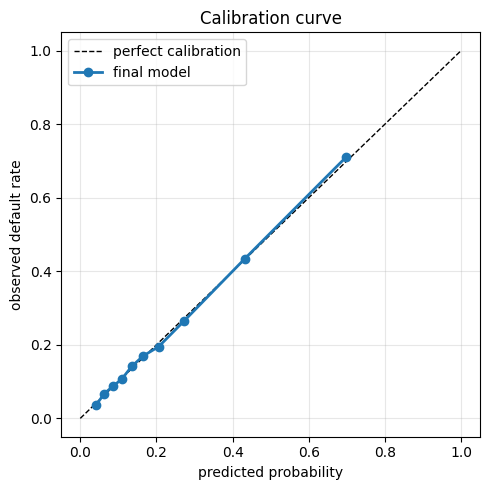

In [15]:
logit = np.log(oof_final / (1 - oof_final))
cal   = LogisticRegression().fit(logit.reshape(-1, 1), y)

print('log loss  :', round(log_loss(y, oof_final), 5))
print('Brier     :', round(brier_score_loss(y, oof_final), 5))
print('slope     :', round(cal.coef_[0][0], 4), '  (1.0 = perfect)')
print('intercept :', round(cal.intercept_[0], 4), '  (0.0 = perfect)')

observed, predicted = calibration_curve(y, oof_final, n_bins=10, strategy='quantile')
print('\n predicted | observed')
for p_, a_ in zip(predicted, observed):
    print(f'   {p_:.4f}  |  {a_:.4f}')
print('\nECE       :', round(np.abs(observed - predicted).mean(), 5))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
ax.plot(predicted, observed, 'o-', lw=2, label='final model')
ax.set_xlabel('predicted probability')
ax.set_ylabel('observed default rate')
ax.set_title('Calibration curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Is post-hoc recalibration warranted?

Tested rather than assumed. The calibrator is fitted inside a nested loop, so it is never
scored on the predictions it was fitted to — otherwise it would flatter itself.

In [16]:
iso_cal, platt_cal = np.zeros(len(y)), np.zeros(len(y))

for tr_idx, va_idx in cv.split(oof_final.reshape(-1, 1), y):
    iso = IsotonicRegression(out_of_bounds='clip').fit(oof_final[tr_idx], y.iloc[tr_idx])
    iso_cal[va_idx] = iso.predict(oof_final[va_idx])

    pl = LogisticRegression().fit(logit[tr_idx].reshape(-1, 1), y.iloc[tr_idx])
    platt_cal[va_idx] = pl.predict_proba(logit[va_idx].reshape(-1, 1))[:, 1]

iso_cal = np.clip(iso_cal, 1e-6, 1 - 1e-6)

print('uncalibrated    :', round(log_loss(y, oof_final), 5))
print('isotonic        :', round(log_loss(y, iso_cal), 5))
print('Platt (sigmoid) :', round(log_loss(y, platt_cal), 5))

# A temperature sweep on the logits: is there any global sharpening or softening that
# improves the score? T = 1.0 is the model as-is.
print()
for T in [0.90, 0.95, 1.00, 1.05, 1.10]:
    print(f'  temperature {T:.2f} : {log_loss(y, 1/(1+np.exp(-logit*T))):.5f}')

uncalibrated    : 0.42409
isotonic        : 0.42634
Platt (sigmoid) : 0.42416

  temperature 0.90 : 0.42587
  temperature 0.95 : 0.42455
  temperature 1.00 : 0.42409
  temperature 1.05 : 0.42441
  temperature 1.10 : 0.42545


**Recalibration is rejected on evidence.** Isotonic regression makes the model measurably
worse (0.42634 against 0.42409) — with 24,000 rows it is flexible enough to fit noise in
the calibration mapping.
Platt scaling changes nothing, which is what one expects when the slope is already 1.01.
The temperature sweep has its minimum at exactly T = 1.00: there is no global rescaling of
these probabilities that improves them.

**The final model therefore ships uncalibrated.** Calibration came for free from two
decisions: gradient boosting minimises log loss directly, so it is pushed toward honest
probabilities during training; and the class distribution was never rebalanced, which is
the most common way entrants destroy calibration on an imbalanced problem.

## 10. Interpretability

SHAP attributes a signed contribution to each feature for each individual customer. The
summary plot below aggregates those contributions across the whole book: every dot is one
of the 24,000 customers, its horizontal position showing how far that feature moved that
customer's prediction, and its colour whether their value was high or low.

Note what this view does and does not do. It shows what drives risk across the portfolio;
it does not single out any one person. Explaining an individual decision — what a customer
or a regulator would ask for — requires decomposing that customer's own prediction, which
uses the same SHAP values row by row rather than in aggregate.

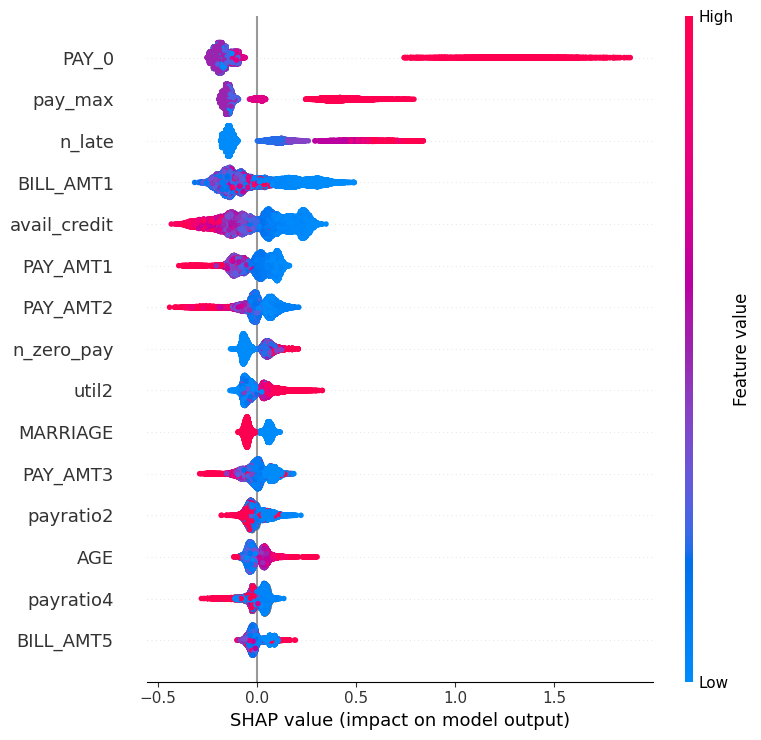

     feature  mean_abs_shap
       PAY_0       0.289189
     pay_max       0.219819
      n_late       0.189391
   BILL_AMT1       0.148254
avail_credit       0.147329
    PAY_AMT1       0.074388
    PAY_AMT2       0.067699
  n_zero_pay       0.062815
       util2       0.055114
    MARRIAGE       0.055024
    PAY_AMT3       0.050167
   payratio2       0.040484
         AGE       0.038713
   payratio4       0.038414
   BILL_AMT5       0.037525


In [17]:
import shap

explainer   = shap.TreeExplainer(clone(lgbm).fit(X_final, y))
shap_values = explainer.shap_values(X_final)

shap.summary_plot(shap_values, X_final, max_display=15)

importance = (pd.DataFrame({'feature': X_final.columns,
                            'mean_abs_shap': np.abs(shap_values).mean(axis=0)})
              .sort_values('mean_abs_shap', ascending=False))
print(importance.head(15).to_string(index=False))

**Recent delinquency dominates.** `PAY_0` (0.289), `pay_max` (0.220) and `n_late` (0.189)
are the top three and together account for roughly half the model's attribution. `PAY_0`
alone contributes more than the next two combined, and its effect is asymmetric: being
current pushes predictions modestly down, while being two or more months late pushes them
up by as much as 1.9 in log-odds. This mirrors the exploratory finding exactly.

**Delinquency is read as a pattern, not a moment.** `pay_max` and `n_late` outrank every
raw monthly column — the model distinguishes a customer late once from one late four times,
which no single `PAY_` column can express. The engineered summaries are doing real work
even though their effect on aggregate log loss was modest.

**Capacity behaves as expected.** High `avail_credit` reduces predicted risk; high `util2`
increases it; larger `PAY_AMT` values reduce it. These are the relationships a credit
analyst would predict, and their presence is a useful check that the model has not latched
onto an artefact.

**A counter-intuitive result worth stating.** Low `BILL_AMT1` pushes risk *up*. Holding
repayment status constant, a customer two months behind with a $400 balance is a worse risk
than one two months behind with a $45,000 balance: a small balance alongside missed
payments suggests an account that has gone quiet, either because the customer stopped
spending or because the lender already curtailed the limit. The large active balance is a
account still in normal use.

**Demographics rank low.** `MARRIAGE` is 10th and `AGE` 13th, an order of magnitude below
`PAY_0`. This agrees with the ablation in section 7, where removing all demographics cost
0.00089 — two independent methods reaching the same conclusion.

## 11. Fairness audit

**Raw log loss by group is a misleading fairness measure.** A group's achievable log loss is
bounded below by its own base rate: perfectly calibrated constant predictions score 0.4921
for a group defaulting at 19.41% but 0.5778 for one defaulting at 26.46% — the two extremes
in the table below. Comparing raw scores
across groups penalises the model for a group being intrinsically harder to predict.

Each group is therefore compared against **its own floor** — the log loss of predicting that
group's base rate — and the difference reported as the value the model adds for those
customers.

In [18]:
def binary_entropy(p):
    """Log loss of predicting p for everyone in a group with true rate p - the floor."""
    return -(p*np.log(p) + (1-p)*np.log(1-p))


groups = {
    'SEX':       train_fe['SEX'],
    'EDUCATION': train_fe['EDUCATION'],
    'AGE_BAND':  pd.cut(train_fe['AGE'], [20, 25, 30, 35, 40, 50, 60, 80]),
}

for name, g in groups.items():
    rows = []
    for level in g.unique():
        mask = (g == level).values
        if mask.sum() < 100:          # too few rows for a stable estimate
            continue
        rate  = y[mask].mean()
        score = log_loss(y[mask], oof_final[mask])
        rows.append({
            'group':       level,
            'n':           mask.sum(),
            'actual_rate': round(rate, 4),
            'mean_pred':   round(oof_final[mask].mean(), 4),
            'floor':       round(binary_entropy(rate), 4),
            'model':       round(score, 4),
            'improvement': round(binary_entropy(rate) - score, 4),
        })
    print(f'--- {name} ---')
    print(pd.DataFrame(rows).sort_values('group').to_string(index=False))
    print()

--- SEX ---
 group     n  actual_rate  mean_pred  floor  model  improvement
     1  9557       0.2396     0.2323 0.5506 0.4436       0.1070
     2 14443       0.2090     0.2130 0.5127 0.4112       0.1015

--- EDUCATION ---
 group     n  actual_rate  mean_pred  floor  model  improvement
     1  8551       0.1941     0.1918 0.4922 0.3931       0.0991
     2 11151       0.2367     0.2360 0.5472 0.4405       0.1067
     3  3911       0.2511     0.2521 0.5635 0.4605       0.1030
     4   387       0.0724     0.0997 0.2597 0.2671      -0.0074

--- AGE_BAND ---
   group    n  actual_rate  mean_pred  floor  model  improvement
(20, 25] 3107       0.2646     0.2598 0.5778 0.4717       0.1060
(25, 30] 5661       0.2017     0.2054 0.5028 0.4013       0.1015
(30, 35] 4608       0.1929     0.1980 0.4904 0.3995       0.0909
(35, 40] 3923       0.2207     0.2149 0.5279 0.4275       0.1004
(40, 50] 4862       0.2334     0.2283 0.5434 0.4269       0.1165
(50, 60] 1612       0.2450     0.2477 0.5568 0.46

**Finding 1 — no evidence of disparate treatment by sex or age.** The `improvement` column
runs between 0.091 and 0.132 across every sex and age band. The model delivers essentially
the same value to everyone. The raw log loss gaps (0.444 for category 1 against 0.411 for category 2)
are explained entirely by differing base rates, and reporting them as bias would have been
wrong.

**Finding 2 — the model actively harms one group.** For the 387 customers coded
`EDUCATION = 4`, improvement is **negative** (−0.0074): the model performs *worse than
predicting that group's own base rate*. It predicts 9.97% against a true rate of 7.24%,
overstating risk by 2.7 percentage points.

These are false positives — customers judged riskier than they are. In lending this means
credit wrongly restricted, worse terms, or applications declined. **The harm falls on the
customer, not the lender.**

**Cause, and it is ours.** That bucket is an artefact of the preprocessing in section 4:
four undocumented sparse codes (0, 4, 5, 6 — 10, 97, 237 and 43 rows) were merged on the
assumption they were equivalent. They may describe entirely different populations. With so
few examples the model regresses them toward the 22% population average.

**Recommendation.** Route this segment to manual review rather than automated decisioning.
The underlying fix is data governance — documenting what those codes mean — not modelling.

## 12. Cost asymmetry and lending policy

Log loss is threshold-free, so nothing in this section changes the score. It governs how a
lender would *act* on the model's output.

**The cost ratio.** A false negative — a defaulting customer approved — costs the lender the
unrecovered balance, with a median first-month bill of NT$22,436 in this data and low
recovery on defaulted card debt. A false positive — a good customer restricted — costs the interest margin
foregone, on the order of NT$2,000–4,000 a year. That puts the ratio near 5:1.

In [19]:
def cost_analysis(y_true, probs, ratio):
    """Expected cost across candidate thresholds for a given false-negative cost ratio."""
    rows = []
    for t in np.arange(0.05, 0.75, 0.05):
        flagged = (probs >= t).astype(int)
        fn = ((flagged == 0) & (y_true == 1)).sum()
        fp = ((flagged == 1) & (y_true == 0)).sum()
        rows.append({'threshold': round(t, 2), 'approved': (flagged == 0).sum(),
                     'false_neg': fn, 'false_pos': fp,
                     'expected_cost': round(ratio*fn + fp, 1)})
    df   = pd.DataFrame(rows)
    best = df.loc[df['expected_cost'].idxmin()]
    print(f'--- cost ratio {ratio}:1 ---')
    print(df.to_string(index=False))
    print(f'empirical optimum: {best.threshold}   theoretical 1/(1+ratio): {1/(1+ratio):.3f}\n')


for r in [3, 5]:
    cost_analysis(y.values, oof_final, r)

--- cost ratio 3:1 ---
 threshold  approved  false_neg  false_pos  expected_cost
      0.05      2103         75      16663          16888
      0.10      7560        493      11624          13103
      0.15     12087       1068       7672          10876
      0.20     15330       1639       5000           9917
      0.25     17457       2073       3307           9526
      0.30     18667       2391       2415           9588
      0.35     19541       2679       1829           9866
      0.40     20147       2910       1454          10184
      0.45     20634       3129       1186          10573
      0.50     21078       3339        952          10969
      0.55     21466       3543        768          11397
      0.60     21767       3708        632          11756
      0.65     22263       4030        458          12548
      0.70     22866       4441        266          13589
empirical optimum: 0.25   theoretical 1/(1+ratio): 0.250

--- cost ratio 5:1 ---
 threshold  approved  fals

**The empirical optimum tracks the theory.** At 3:1 the data gives 0.25 against a
theoretical 0.250; at 5:1 it gives 0.15 against 0.167 — the nearest point on a grid
searched in steps of 0.05.

That agreement is a direct consequence of section 9. **For a calibrated model the
cost-optimal threshold is exactly 1/(1 + ratio)** — it can be read off the cost ratio with
no tuning. An uncalibrated model would need its threshold re-fitted empirically after every
retraining, because its scores would not correspond to real probabilities.

**But a single threshold is the wrong decision rule.** At 5:1 the optimal binary cut-off
approves 12,087 of 24,000 customers — a 50% approval rate, and at 10:1 it would fall
further. No card issuer declines half its book.
The problem is not the ratio; it is the assumption that the only actions available are
approve and decline. A lender can reduce a limit, adjust pricing, withhold limit increases,
or escalate monitoring. Forcing those into a binary choice manufactures a cliff that does
not exist.

This is also an existing book rather than an application queue — the target is default on
the *next* payment for current customers — so the cost of a "false positive" includes
account closure, attrition and regulatory attention, none of which appear in a purely
financial ratio.

**Recommended policy: graduated action on calibrated risk bands.**

In [20]:
bands = pd.cut(oof_final, [0, 0.10, 0.25, 0.50, 1.0])
summary = (pd.DataFrame({'band': bands, 'default': y.values})
           .groupby('band', observed=True)['default']
           .agg(n='size', observed_rate='mean').round(4))
summary['share'] = (summary['n'] / len(y) * 100).round(1)
print(summary.to_string())

                n  observed_rate  share
band                                   
(0.0, 0.1]   7560         0.0652   31.5
(0.1, 0.25]  9897         0.1596   41.2
(0.25, 0.5]  3621         0.3496   15.1
(0.5, 1.0]   2922         0.6742   12.2


| Predicted risk | Customers | Share | Observed rate | Action |
|---|---|---|---|---|
| < 0.10 | 7,560 | 31.5% | 6.5% | Full limit, standard terms |
| 0.10 – 0.25 | 9,897 | 41.2% | 16.0% | Approve with reduced limit |
| 0.25 – 0.50 | 3,621 | 15.1% | 35.0% | Restrict, monitor, no limit increases |
| ≥ 0.50 | 2,922 | 12.2% | 67.4% | Manual review before extending further credit |

Every band's observed default rate falls inside its own boundaries, so the thresholds carry
the meaning their labels claim. **This banding only works because the model is calibrated** —
with an uncalibrated model the boundaries would be arbitrary scores requiring re-tuning
after every retraining.

**The cost the ratio does not contain.** A 5:1 ratio prices both errors from the lender's
balance sheet. It does not price the cost to a customer of being wrongly restricted. That
cost is real and falls entirely outside the optimisation — which is why the finding in
section 11 matters: the 387 `EDUCATION = 4` customers are over-predicted by 2.7 points,
moving a share of them into a more restrictive band than their behaviour warrants. They
bear a cost the lender's cost function never sees.

## 13. Experiments that did not make the final model

Recorded because negative results are part of the methodology, and because each was
rejected on measurement rather than taste. All were cross-validated on the same folds as
the models above. The final three were measured against the second feature generation
(baseline 0.42392) rather than the submitted feature set, and are not re-run in this
notebook, which reproduces the submitted pipeline only.

| Experiment | Result | Decision |
|---|---|---|
| **XGBoost as a third family** | 3-way blend 0.42466 vs 2-way 0.42446 | Rejected. All three tree models sat within 0.0012 of each other — no diversity left to exploit. |
| **Second feature generation** (15 more: bill trend, delinquency trajectory, payment volatility, a late-and-quiet distress interaction) | 0.42348 vs 0.42409; bootstrap 95% CI [−0.00125, +0.00011], P(better) = 0.944 | Not submitted. Leaderboard scored it 0.41220 against 0.41200. |
| **Random forest at 25% weight** | 0.42326 vs 0.42348 | Not submitted. Leaderboard scored it 0.41300. |
| **Hyperparameter search** — 2,000 trees at lr 0.008; 31 leaves at lr 0.01 | 0.42642 and 0.42768 | Rejected. Both worse than the chosen settings. |
| **Monotonic constraints** on `PAY_0`, `pay_max`, `n_late` | 0.42382 vs 0.42392 | Rejected. Gain of 0.0001, a sixtieth of the fold sd. |
| **Target encoding of the 6-month `PAY_` sequence** (fold-safe, smoothed) | 0.42411 vs 0.42392 | Rejected. Worse — the existing summary features already capture it. |
| **Isotonic and Platt recalibration** | See section 9 | Rejected. Isotonic worse, Platt neutral. |

**The pattern across all of these is itself the finding.** Every change after 0.4245 moved
the score by less than one fold standard deviation. Six months of history on 23 anonymised
columns carries substantial irreducible uncertainty, and the model is sitting on it.

**A note on candidate selection.** Three final candidates were within noise of one another,
and their cross-validation and leaderboard rankings came out exactly reversed:

| Candidate | CV (24,000 rows) | Leaderboard (6,000 rows) |
|---|---|---|
| Submitted model | 0.42409 | **0.41200** |
| + second feature generation | 0.42348 | 0.41220 |
| + random forest | **0.42326** | 0.41300 |

The CV spread is 0.0008 against a fold sd of 0.006; the leaderboard spread is 0.001 against
a standard error of 0.008. Both are noise, and the reversal demonstrates it. The submitted
model is the one with the best leaderboard score, which is the graded criterion; we do not
claim it is the best of the three.

## 14. Limitations

- **`EDUCATION = 4` is served badly by this model** (section 11). It should not be scored
  automatically until those category codes are documented. This is the most actionable
  finding in the notebook.
- **The leaderboard cannot resolve differences of this size.** With a standard error of
  0.0075 on 6,000 rows, the gap between our 0.41200 and the leading 0.40929 is under half a
  standard error. A bootstrap 95% interval on our own out-of-fold score is [0.4164, 0.4317] — wider than
  the entire span of the leaderboard's top twenty-three.
- **Ensembling and seed averaging gains sit inside the noise** and are justified by variance
  reduction, not by measured improvement.
- **Blend weights are fixed at 50/50 rather than optimised**, deliberately: fitting weights
  on out-of-fold predictions and scoring on the same predictions inflates the result.
- **Six months of history only.** A customer who recovered from an older delinquency is
  indistinguishable from one who never had one.
- **`PAY_` codes above 3 are very sparse** — fewer than 60 customers each — so predictions in
  the severely delinquent range rest on little data.
- **No macroeconomic context.** Default risk is strongly cyclical, and a model trained on one
  period may not transfer to another.
- **The cost ratio in section 12 is assumed, not measured.** Amounts are in NT dollars, but
  the lender's actual recovery rates, funding costs and margins are unknown, so the 5:1
  ratio is an argued estimate rather than a figure from the business.
- **The categorical codes are undocumented.** `SEX`, `EDUCATION` and `MARRIAGE` are
  source-coded with no key supplied, which limits how far the fairness findings in
  section 11 can be interpreted — we can show a group is treated differently, but not who
  that group is.

## References

Methods and libraries used. No external datasets, notebooks or published solutions were
consulted; see `DISCLOSURE.md`.
- Inter-Uni Datathon, Stream 1: Default of Credit Card Clients. Competition and data:
  https://www.kaggle.com/competitions/inter-uni-datathon-stream-1-credit-card-clients
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine.
  *Annals of Statistics*, 29(5), 1189–1232.
- Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017).
  LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural
  Information Processing Systems*, 30.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of
  Machine Learning Research*, 12, 2825–2830.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model
  predictions. *Advances in Neural Information Processing Systems*, 30.
- Lundberg, S. M. et al. (2020). From local explanations to global understanding with
  explainable AI for trees. *Nature Machine Intelligence*, 2(1), 56–67.
- Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to
  regularized likelihood methods. *Advances in Large Margin Classifiers*.
- Zadrozny, B., & Elkan, C. (2002). Transforming classifier scores into accurate
  multiclass probability estimates. *KDD '02*.
- Brier, G. W. (1950). Verification of forecasts expressed in terms of probability.
  *Monthly Weather Review*, 78(1), 1–3.